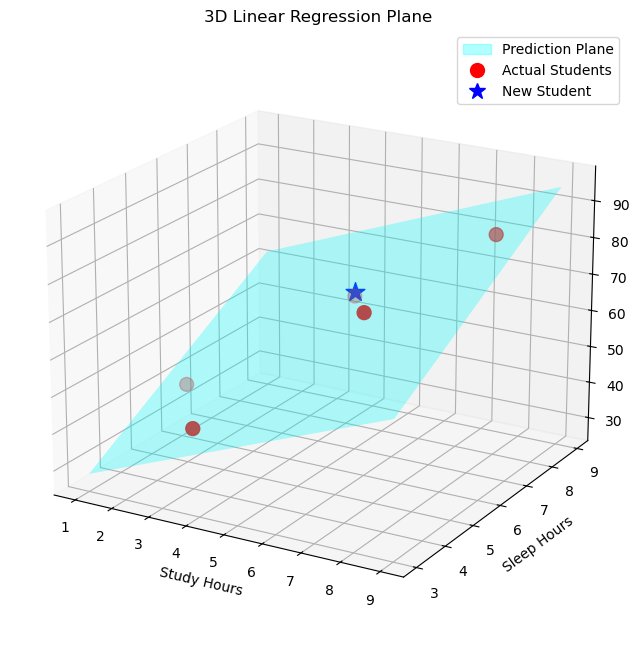

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression

# 1. Prepare data
data = {
    'Study_Hours': [2, 5, 8, 3, 6],
    'Sleep_Hours': [5, 7, 8, 4, 6],
    'Exam_Score':  [45, 66, 84, 40, 68]
}
df = pd.DataFrame(data)
X = df[['Study_Hours', 'Sleep_Hours']]
y = df['Exam_Score']

# 2. Train model
model = LinearRegression()
model.fit(X, y)

# 3. Create a coordinate grid to plot the plane
x_range = np.linspace(1, 9, 20)
y_range = np.linspace(3, 9, 20)
x_surf, y_surf = np.meshgrid(x_range, y_range)

# Predict scores across the entire grid surface
grid_df = pd.DataFrame({'Study_Hours': x_surf.ravel(), 'Sleep_Hours': y_surf.ravel()})
z_surf = model.predict(grid_df).reshape(x_surf.shape)

# 4. Generate the 3D Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the model's prediction plane
ax.plot_surface(x_surf, y_surf, z_surf, color='cyan', alpha=0.3)

# Plot training points
ax.scatter(df['Study_Hours'], df['Sleep_Hours'], df['Exam_Score'], color='red', s=100)

# Plot the new prediction point (5h study, 7h sleep -> 67.0 score)
ax.scatter([5], [7], [67.0], color='blue', marker='*', s=200)

# Labels and styling
ax.set_xlabel('Study Hours')
ax.set_ylabel('Sleep Hours')
ax.set_zlabel('Exam Score')
ax.set_title('3D Linear Regression Plane')

# Create a clean manual legend
plane_proxy = mpatches.Patch(color='cyan', alpha=0.3, label='Prediction Plane')
student_proxy = mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='Actual Students')
new_student_proxy = mlines.Line2D([], [], color='blue', marker='*', linestyle='None', markersize=12, label='New Student')
ax.legend(handles=[plane_proxy, student_proxy, new_student_proxy])

# Adjust the viewing angle to see the slope clearly
ax.view_init(elev=20, azim=-60)

plt.show()